Usando o exemplo 499

In [19]:
%pip install pandas numpy seaborn tensorflow
%pip install nltk
%pip install lime
%pip install imbalanced-learn
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap


from lime import lime_text
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer

# Camada de Atenção (Mover para antes da definição do modelo)
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3
        self.W = self.add_weight(name='att_W', shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(name='att_b', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        self.u = self.add_weight(name='att_u', shape=(input_shape[1], 1), initializer='normal', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        et = K.squeeze(K.tanh(K.dot(x, self.W) + self.b), axis=-1)
        at = K.softmax(et, axis=1)
        at = K.expand_dims(at, axis=-1)
        output = x * at
        output = K.sum(output, axis=1)
        self.attention_weights = at  # Armazenar os pesos para visualização
        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        config = super().get_config().copy()
        return config

In [21]:
df = pd.read_csv('../spam.csv')

In [22]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df.shape

(5572, 2)

<Axes: xlabel='Category', ylabel='count'>

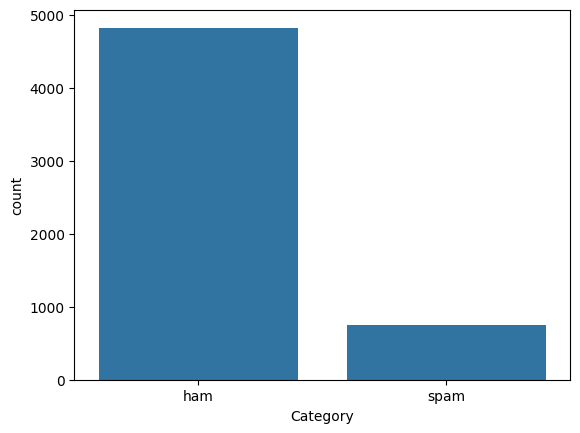

In [24]:
sns.countplot(x='Category', data=df)

**Pré-Processamento**

In [25]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [27]:
df["clean_text"] = df["Message"].apply(preprocess_text)

In [28]:
df.head(5)

,Category,Message,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


<Axes: xlabel='Category', ylabel='count'>

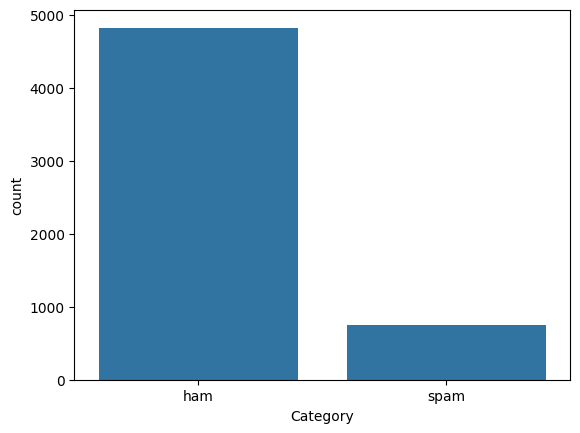

In [29]:
sns.countplot(x="Category", data=df) # validando se mudou as classes

In [30]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Category'])

In [31]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [32]:
#tokenização e padding
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

**LSTM**

In [33]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [34]:
# Definir o modelo LSTM
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(128, return_sequences=True))  # LSTM com retorno de sequências para atenção
model.add(AttentionLayer())  # Adicionar a camada de atenção
model.add(Dense(3, activation='softmax'))  # 3 saídas para sentimentos (negativo, neutro, positivo)

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [35]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy se y_train for numérico
              metrics=['accuracy'])

In [36]:
# Treinar o modelo
history = model.fit(X_train_pad, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)  # Validação durante o treinamento

Epoch 1/10


c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\optimizers\base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['sequential_1/attention_layer_1/att_u'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


126/126 ━━━━━━━━━━━━━━━━━━━━ 95s 488ms/step - accuracy: 0.9040 - loss: 0.2855 - val_accuracy: 0.9552 - val_loss: 0.1260
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 57s 455ms/step - accuracy: 0.9771 - loss: 0.0752 - val_accuracy: 0.9709 - val_loss: 0.0976
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 77s 405ms/step - accuracy: 0.9873 - loss: 0.0440 - val_accuracy: 0.9709 - val_loss: 0.0964
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 97s 514ms/step - accuracy: 0.9928 - loss: 0.0296 - val_accuracy: 0.9686 - val_loss: 0.1125
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 72s 554ms/step - accuracy: 0.9948 - loss: 0.0224 - val_accuracy: 0.9731 - val_loss: 0.1104
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 64s 410ms/step - accuracy: 0.9963 - loss: 0.0180 - val_accuracy: 0.9798 - val_loss: 0.1055
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 128s 763ms/step - accuracy: 0.9970 - loss: 0.0147 - val_accuracy: 0.9776 - val_loss: 0.1098
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 175s 987ms/step - accuracy: 0.9973 - loss: 0.0128 - v

**OVERSAMPLING**

In [37]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)  # Define um estado aleatório para reprodutibilidade
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_pad, y_train)

In [38]:
# treino do modelo com os dados desbalanceados
history = model.fit(X_train_resampled, y_train_resampled,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 211s 953ms/step - accuracy: 0.9893 - loss: 0.0411 - val_accuracy: 0.9896 - val_loss: 0.0322
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 273s 988ms/step - accuracy: 0.9937 - loss: 0.0218 - val_accuracy: 0.9896 - val_loss: 0.0316
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 311s 1s/step - accuracy: 0.9950 - loss: 0.0164 - val_accuracy: 0.9922 - val_loss: 0.0203
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 272s 1s/step - accuracy: 0.9964 - loss: 0.0135 - val_accuracy: 0.9948 - val_loss: 0.0113
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 321s 1s/step - accuracy: 0.9964 - loss: 0.0137 - val_accuracy: 0.9922 - val_loss: 0.0178
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.9965 - loss: 0.0122 - val_accuracy: 0.9922 - val_loss: 0.0142
Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9967 - loss: 0.0102 - val_accuracy: 0.9948 - val_loss: 0.0092
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 200s 799ms/step - accuracy: 0.9970 - loss: 0.0086 -

<Axes: xlabel='label_encoded', ylabel='count'>

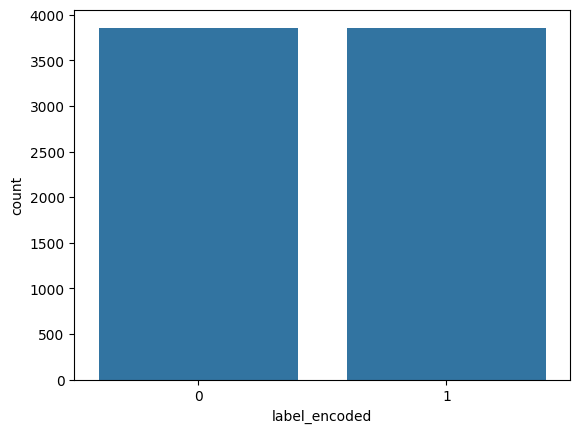

In [39]:
#verificar a nova distribuição de classes
sns.countplot(x=y_train_resampled)

**Métricas**

In [40]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))


35/35 ━━━━━━━━━━━━━━━━━━━━ 24s 401ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       966
           1       0.91      0.91      0.91       149

    accuracy                           0.98      1115
   macro avg       0.95      0.95      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [41]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.9758
Precisão: 0.9759
Recall: 0.9758
F1-Score: 0.9758


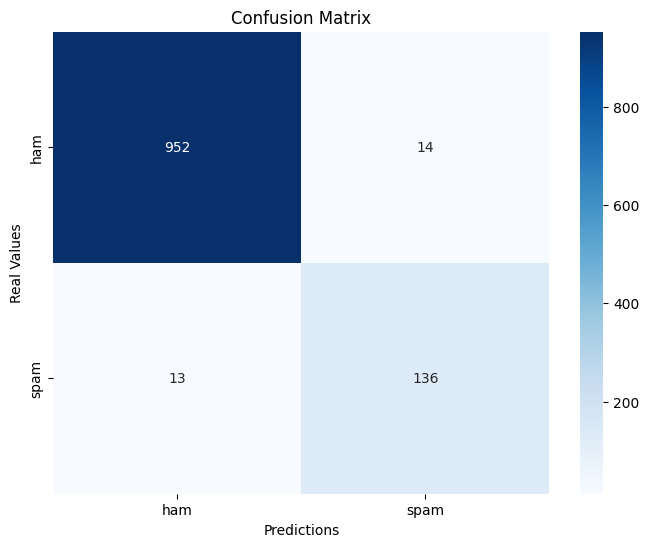

In [42]:
# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [43]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    predictions = model.predict(padded_sequences)
    return predictions  # Já retorna probabilidades (softmax)

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
sample_seq = tokenizer.texts_to_sequences([sample_text])
sample_pad = pad_sequences(sample_seq, maxlen=max_len)
pred_probs = model.predict(sample_pad)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Número da linha no X_test: 499
Original text:
noe shes da car later c lar im wearing short
Classe real: ham
Classe predita: ham
157/157 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step
[(np.str_('noe'), -0.0013366476227052928), (np.str_('later'), -0.0013040610217537397), (np.str_('car'), -0.001231745710545076), (np.str_('shes'), -0.0011698467911547333), (np.str_('im'), -0.0011125772028286083), (np.str_('short'), -0.0010829073898997966), (np.str_('lar'), -0.001079787051951189), (np.str_('wearing'), -0.0009744894424467062), (np.str_('da'), -0.000969644530582873), (np.str_('c'), -0.0004565468675530753)]


In [44]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
noe: -0.0013
later: -0.0013
car: -0.0012
shes: -0.0012
im: -0.0011
short: -0.0011
lar: -0.0011
wearing: -0.0010
da: -0.0010
c: -0.0005


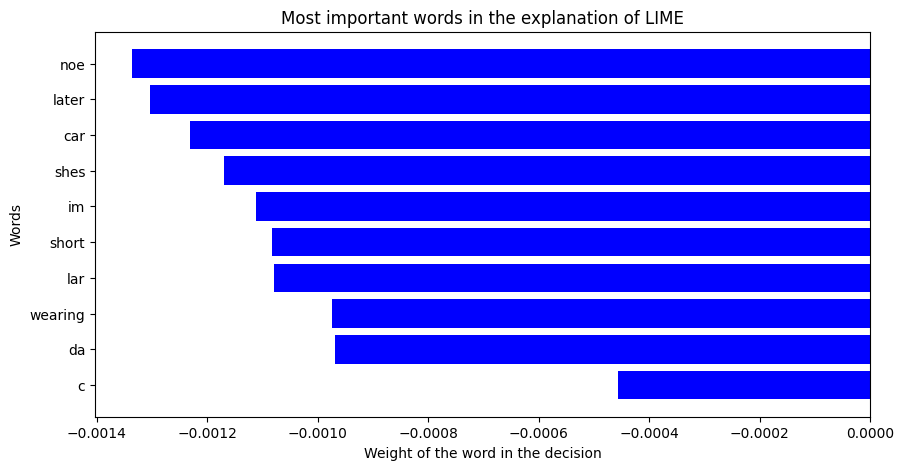

In [45]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [46]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

noe: -0.0013366476227052928
later: -0.0013040610217537397
car: -0.001231745710545076
shes: -0.0011698467911547333
im: -0.0011125772028286083
short: -0.0010829073898997966
lar: -0.001079787051951189
wearing: -0.0009744894424467062
da: -0.000969644530582873
c: -0.0004565468675530753


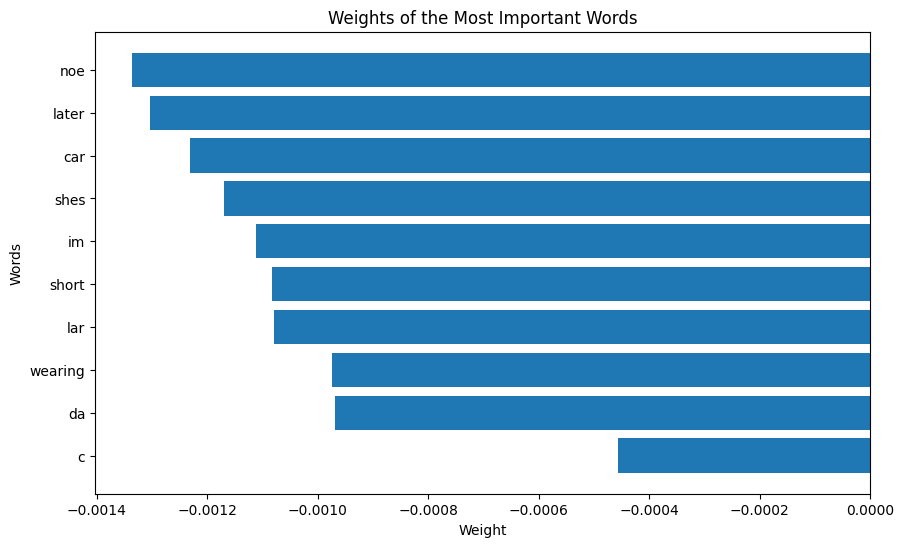

In [47]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [48]:
le.classes_

array(['ham', 'spam'], dtype=object)

Texto usado na explicação:
noe shes da car later c lar im wearing short
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Classe prevista pelo modelo: 0
Probabilidades: [9.9999976e-01 1.2474760e-07 1.1733177e-07]

Palavras do exemplo e seus pesos na decisão do modelo:
      Feature    Weight
43      later  0.325386
896     short  0.141627
234       car  0.116816
3          im  0.065009
229       lar -0.014050
473       noe -0.105171
351      shes -0.125137
45         da -0.152520
2896  wearing -0.214186
69          c -0.375105


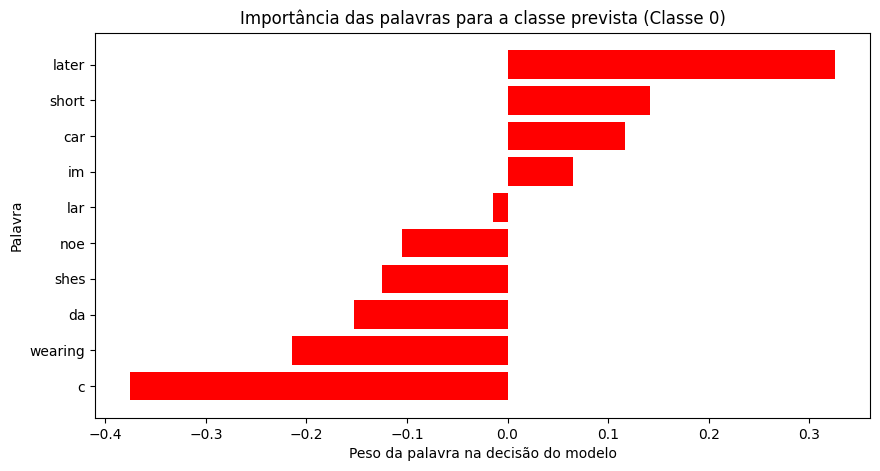

In [49]:
# =====================================================
# USAR O MESMO EXEMPLO DO LIME
# =====================================================

lime_idx = 499  # mesmo índice usado no LIME

# reconstruir palavras da sequência usada no modelo
tokens = X_test_pad[lime_idx]

words = [
    tokenizer.index_word.get(int(token), "")
    for token in tokens
]

# remover padding
words = [w for w in words if w != ""]

sample_text = " ".join(words)

print("Texto usado na explicação:")
print(sample_text)

# =====================================================
# ETAPA 1: IMPORTÂNCIA GLOBAL DAS PALAVRAS (LSTM)
# =====================================================

# pesos da camada Embedding
embedding_weights = model.layers[0].get_weights()[0]

# nomes das features
nomes_das_features = [
    tokenizer.index_word.get(i, "<OOV>")
    for i in range(1, embedding_weights.shape[0] + 1)
]

# pesos da camada Dense final
dense_weights = model.layers[-1].get_weights()[0]

num_classes = dense_weights.shape[1]

importancias_das_features = []

for class_index in range(num_classes):

    class_weights = dense_weights[:, class_index]

    word_importances = np.dot(embedding_weights, class_weights)

    importancias_da_classe = pd.DataFrame({
        'Feature': nomes_das_features,
        'Weight': word_importances
    })

    importancias_da_classe = importancias_da_classe.sort_values(
        by='Weight',
        ascending=False
    )

    importancias_das_features.append(importancias_da_classe)

# =====================================================
# ETAPA 2: PREVISÃO DO MESMO EXEMPLO DO LIME
# =====================================================

# usar exatamente a mesma entrada usada no LIME
padded_sequence = X_test_pad[lime_idx:lime_idx+1]

prediction = model.predict(padded_sequence)

predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista pelo modelo: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# =====================================================
# ETAPA 3: FILTRAR APENAS PALAVRAS DO EXEMPLO
# =====================================================

importancias_da_classe_prevista = importancias_das_features[predicted_class_index]

palavras_exemplo = set(words)

importancias_exemplo_lstm = importancias_da_classe_prevista[
    importancias_da_classe_prevista['Feature'].apply(lambda x: x in palavras_exemplo)
]

importancias_exemplo_lstm = importancias_exemplo_lstm.sort_values(
    by='Weight',
    ascending=False
)

print("\nPalavras do exemplo e seus pesos na decisão do modelo:")
print(importancias_exemplo_lstm[['Feature','Weight']])

# =====================================================
# ETAPA 4: PLOT
# =====================================================

plt.figure(figsize=(10,5))

plt.barh(
    importancias_exemplo_lstm['Feature'],
    importancias_exemplo_lstm['Weight'],
    color="red"
)

plt.xlabel("Peso da palavra na decisão do modelo")
plt.ylabel("Palavra")

plt.title(
    f"Importância das palavras para a classe prevista (Classe {predicted_class_index})"
)

plt.gca().invert_yaxis()

plt.show()

Shapley

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 244ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
6607/6607 ━━━━━━━━━━━━━━━━━━━━ 1449s 219ms/step


100%|██████████| 1/1 [27:37<00:00, 1657.10s/it]


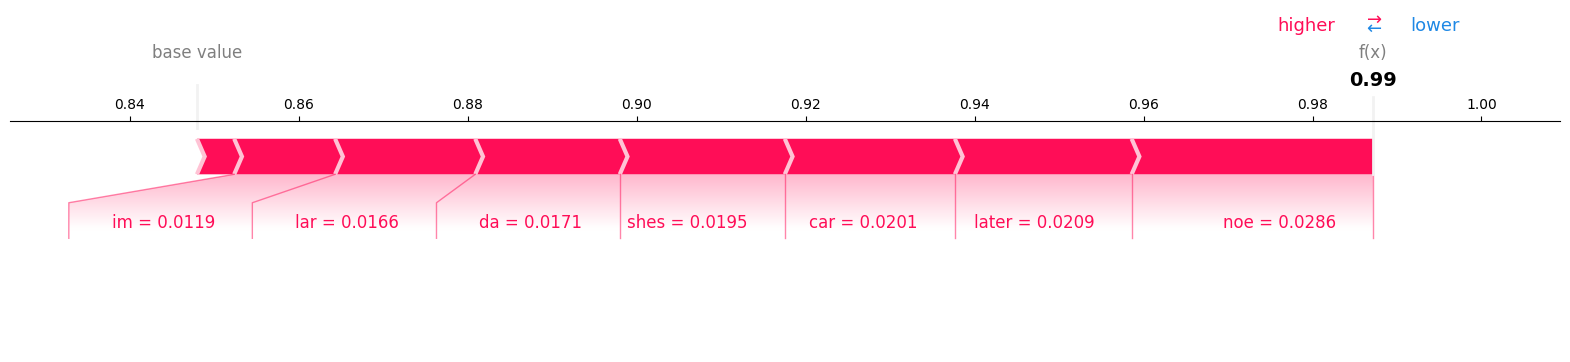

In [50]:
# =========================
# Definir índice da mesma instância usada no LIME
# =========================

lime_idx = 499

if lime_idx >= len(X_test_pad):
    raise ValueError("lime_idx fora do intervalo")

# Instância
X_instance = X_test_pad[lime_idx:lime_idx+1]

# =========================
# Descobrir classe predita automaticamente
# =========================

pred_probs = model.predict(X_instance)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]

# =========================
# Criar função para explicar classe predita
# =========================

def predict_fn(x):
    preds = model.predict(x)
    return preds[:, pred_class_idx]

# =========================
# Criar background
# =========================

background_size = 100
background = X_train_pad[
    np.random.choice(
        X_train_pad.shape[0],
        min(background_size, X_train_pad.shape[0]),
        replace=False
    )
]

# =========================
# Criar explainer
# =========================

explainer = shap.KernelExplainer(predict_fn, background)

# =========================
# Calcular SHAP values
# =========================

shap_values = explainer.shap_values(X_instance)

shap_values = np.array(shap_values[0]).reshape(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# =========================
# Converter tokens → palavras
# =========================

tokens = X_instance[0]

words = [
    tokenizer.index_word.get(int(token), "")
    for token in tokens
]

# =========================
# Remover PAD
# =========================

valid_indices = [i for i, w in enumerate(words) if w != ""]

words = [words[i] for i in valid_indices]
shap_values = shap_values[valid_indices]

# =========================
# Ordenar por impacto absoluto
# =========================

sorted_indices = np.argsort(np.abs(shap_values))[::-1]

top_k = 15
sorted_indices = sorted_indices[:top_k]

words = [words[i] for i in sorted_indices]
shap_values = shap_values[sorted_indices]

# =========================
# Criar labels formatados: [palavra = valor]
# =========================

# Criamos uma lista de strings combinando a palavra e o valor do SHAP formatado
formatted_labels = [
    f"{word} = {val:.4f}" 
    for word, val in zip(words, shap_values)
]

# =========================
# Force plot final com labels customizados
# =========================

shap.force_plot(
    expected_value, 
    shap_values, 
    feature_names=formatted_labels, # Usamos a lista formatada aqui
    matplotlib=True
)